# 08 · 의사결정 분석 (통합 + 비용 민감 threshold)

> 역할: 모든 모델을 한 표로 모으고, '단순 예측'을 '의사결정'으로 바꾼다.
> 핵심: threshold 0.5는 임의값이다. **놓친 백오더 vs 헛경보의 비용**으로 threshold를 정한다.

흐름: 통합 비교표 -> 최고 모델 선택 -> threshold 0.5의 문제 -> F1 최적 -> 보정(calibration)
-> 비용 민감 threshold -> 비용비율 민감도 -> 이론 vs 실측 -> 오류 분석 -> 결론

## 0. 환경 설정
이 노트북은 학습을 하지 않는다. 02의 val 데이터와, 각 모델이 저장한 val 확률 파일을 불러와 분석만 한다.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                             f1_score, recall_score, precision_score, confusion_matrix)
from sklearn.calibration import calibration_curve

from utils import load_processed

PROJECT_ROOT = Path(r"C:\Users\Administrator\Desktop\딥러닝응용\TermProject")
OUT_DIR     = PROJECT_ROOT / "processed"
NB_DIR      = PROJECT_ROOT / "notebooks_v1"
RESULTS_CSV = NB_DIR / "results.csv"

_, val_df, _ = load_processed(OUT_DIR)
TARGET = "went_on_backorder"
feature_cols = [c for c in val_df.columns if c != TARGET]
y_val = val_df[TARGET].values.astype(int)
print("val:", len(y_val), " 양성:", int(y_val.sum()), "({:.3%})".format(y_val.mean()))

val: 337572  양성: 2259 (0.669%)


## 1. 통합 비교표
results.csv에 쌓인 모든 모델을 PR_AUC 내림차순으로.

In [2]:
res = pd.read_csv(RESULTS_CSV).drop_duplicates(subset="model", keep="last")
res = res.sort_values("PR_AUC", ascending=False).reset_index(drop=True)
res[["model", "PR_AUC", "ROC_AUC", "Recall", "Precision", "F1"]]

,model,PR_AUC,ROC_AUC,Recall,Precision,F1
0,XGBoost,0.2438,0.9618,0.8836,0.0598,0.1120
1,LightGBM,0.2237,0.9580,0.8907,0.0557,0.1048
2,MLP_3_focal,0.1927,0.9463,0.1983,0.3109,0.2422
3,MLP_4_focal_dropout,0.1859,0.9421,0.1301,0.3387,0.1880
4,MLP_1_plain_BCE,0.1859,0.9411,0.0217,0.4298,0.0413
5,MLP_2_weighted,0.1662,0.9469,0.8907,0.0451,0.0859
6,MLP_5_focal_drop_bn,0.1638,0.9443,0.0044,0.2041,0.0087
7,FT_Transformer,0.1446,0.9338,0.0713,0.2800,0.1136
8,MLP_6_undersample,0.1239,0.9328,0.7627,0.0625,0.1156
9,TabNet,0.0932,0.9193,0.9172,0.0241,0.0470


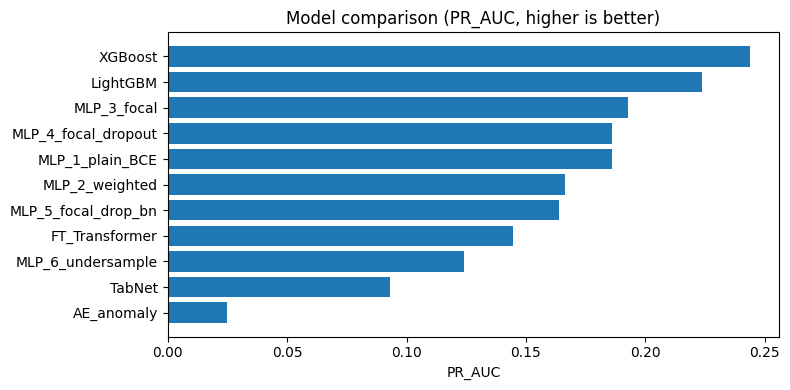

In [3]:
plt.figure(figsize=(8, 4))
plt.barh(res["model"][::-1], res["PR_AUC"][::-1])
plt.xlabel("PR_AUC")
plt.title("Model comparison (PR_AUC, higher is better)")
plt.tight_layout()
plt.show()

## 2. 최고 모델(운영 모델) 선택
각 모델이 저장한 val 확률 파일을 모아, y_val 대비 PR_AUC가 가장 높은 것을 '운영 모델'로 쓴다.
(아직 안 돌린 모델은 확률 파일이 없어 자동으로 빠진다.)

In [4]:
files = sorted(glob.glob(str(NB_DIR / "*_val_prob.npy")) + glob.glob(str(NB_DIR / "*_val_score.npy")))
cands = {}
for f in files:
    p = np.load(f)
    if len(p) == len(y_val):
        cands[Path(f).name] = p

best_file, best_ap = None, -1
for name, p in cands.items():
    ap = average_precision_score(y_val, p)
    print(f"{name:30s} PR_AUC {ap:.4f}")
    if ap > best_ap:
        best_ap, best_file = ap, name

prob = cands[best_file]
print("\n운영 모델:", best_file, " PR_AUC", round(best_ap, 4))

ae_val_score.npy               PR_AUC 0.0250
ft_transformer_val_prob.npy    PR_AUC 0.1446
lgb_val_prob.npy               PR_AUC 0.2237


mlp_best_val_prob.npy          PR_AUC 0.1638
tabnet_val_prob.npy            PR_AUC 0.0932
xgb_val_prob.npy               PR_AUC 0.2438

운영 모델: xgb_val_prob.npy  PR_AUC 0.2438


## 3. threshold 0.5의 문제
같은 확률이라도 어디서 자르느냐(threshold)에 따라 Recall/Precision이 완전히 달라진다.
0.5는 그냥 기본값일 뿐, 백오더 문제에 맞는 값이 아니다.

threshold 0.3: Recall 0.944  Precision 0.041
threshold 0.5: Recall 0.884  Precision 0.060
threshold 0.7: Recall 0.793  Precision 0.089


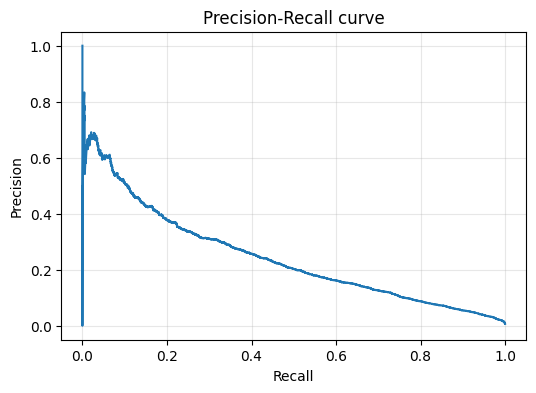

In [5]:
for t in [0.3, 0.5, 0.7]:
    pred = (prob >= t).astype(int)
    print(f"threshold {t}: Recall {recall_score(y_val, pred):.3f}  "
          f"Precision {precision_score(y_val, pred, zero_division=0):.3f}")

prec, rec, _ = precision_recall_curve(y_val, prob)
plt.figure(figsize=(6, 4))
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall curve")
plt.grid(alpha=0.3); plt.show()

## 4. F1 최적 threshold
Precision과 Recall의 균형(F1)이 가장 좋은 threshold를 훑어서 찾는다.

In [6]:
def best_threshold_by_f1(y, p):
    ts = np.linspace(0.01, 0.99, 99)
    f1s = [f1_score(y, (p >= t).astype(int), zero_division=0) for t in ts]
    i = int(np.argmax(f1s))
    return ts[i], f1s[i]

t_f1, f1_best = best_threshold_by_f1(y_val, prob)
print("F1 최적 threshold:", round(t_f1, 3), " F1:", round(f1_best, 3))

F1 최적 threshold: 0.96  F1: 0.313


## 5. 확률 보정 (Calibration)
모델이 "0.8"이라 했을 때 실제로 80%가 백오더인지 본다. 대각선에 가까울수록 잘 보정된 것.
불균형 가중·Focal을 쓰면 확률이 왜곡되기 쉬워서, 아래 비용 공식(이론 threshold)이 안 맞을 수 있다.

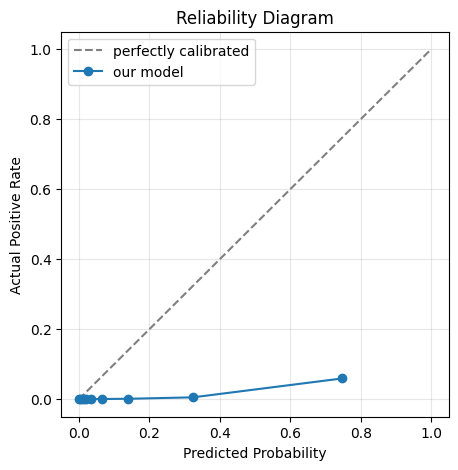

In [7]:
frac_pos, mean_pred = calibration_curve(y_val, prob, n_bins=10, strategy="quantile")
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "--", color="gray", label="perfectly calibrated")
plt.plot(mean_pred, frac_pos, marker="o", label="our model")
plt.xlabel("Predicted Probability"); plt.ylabel("Actual Positive Rate"); plt.title("Reliability Diagram")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 6. 비용 민감 threshold
가정: **놓친 백오더(FN)가 헛경보(FP)보다 C_FN/C_FP 배 비싸다.**
총비용 = C_FN x (놓친 수) + C_FP x (헛경보 수). 이 비용이 가장 작은 threshold를 찾는다.

In [8]:
def total_cost(y, p, t, c_fn, c_fp):
    pred = (p >= t).astype(int)
    fn = int(((pred == 0) & (y == 1)).sum())   # 놓친 백오더
    fp = int(((pred == 1) & (y == 0)).sum())   # 헛경보
    return c_fn * fn + c_fp * fp

def best_threshold_by_cost(y, p, c_fn, c_fp):
    ts = np.linspace(0.001, 0.999, 200)
    costs = [total_cost(y, p, t, c_fn, c_fp) for t in ts]
    i = int(np.argmin(costs))
    return ts[i], costs[i]

C_FN, C_FP = 10, 1   # 놓친 백오더가 헛경보보다 10배 비싸다고 가정
t_cost, c_best = best_threshold_by_cost(y_val, prob, C_FN, C_FP)
pred = (prob >= t_cost).astype(int)
print("비용 최적 threshold:", round(t_cost, 3))
print("  Recall:", round(recall_score(y_val, pred), 3),
      " 플래그 비율:", round(float(pred.mean()), 3),
      " 총비용:", c_best)

비용 최적 threshold: 0.909
  Recall: 0.525  플래그 비율: 0.018  총비용: 15708


## 7. 비용비율 민감도 분석
정확한 비용을 모르니, 비율을 바꿔가며 최적 threshold와 Recall이 어떻게 변하는지 본다.
(비용이 클수록 threshold가 낮아져 더 많이 잡는다 = Recall 상승)

In [9]:
rows = []
for ratio in [2, 5, 10, 20]:
    t, c = best_threshold_by_cost(y_val, prob, ratio, 1)
    pred = (prob >= t).astype(int)
    rows.append({
        "C_FN:C_FP": f"{ratio}:1",
        "최적 t*": round(t, 3),
        "Recall": round(recall_score(y_val, pred), 3),
        "Precision": round(precision_score(y_val, pred, zero_division=0), 3),
        "플래그비율": round(float(pred.mean()), 3),
    })
pd.DataFrame(rows)

,C_FN:C_FP,최적 t*,Recall,Precision,플래그비율
0,2:1,0.984,0.089,0.526,0.001
1,5:1,0.959,0.339,0.294,0.008
2,10:1,0.909,0.525,0.193,0.018
3,20:1,0.834,0.675,0.136,0.033


## 8. 이론 threshold vs 실측
확률이 잘 보정돼 있으면 비용 최적 threshold는 이론적으로 t* = C_FP / (C_FP + C_FN).
실측(훑어서 찾은 값)과 비교해 둘이 비슷하면 보정이 잘 된 것, 많이 다르면 보정이 필요한 것.

In [10]:
for ratio in [2, 5, 10, 20]:
    t_emp, _ = best_threshold_by_cost(y_val, prob, ratio, 1)
    t_theory = 1 / (ratio + 1)   # C_FP/(C_FP+C_FN)
    print(f"{ratio:2d}:1   실측 t* {t_emp:.3f}   이론 t* {t_theory:.3f}")

 2:1   실측 t* 0.984   이론 t* 0.333


 5:1   실측 t* 0.959   이론 t* 0.167


10:1   실측 t* 0.909   이론 t* 0.091


20:1   실측 t* 0.834   이론 t* 0.048


## 9. 오류 분석 - 놓친 백오더는 어떤 것들인가
비용 최적 threshold에서 놓친 양성(실제 Yes인데 No로 예측)과 잡은 양성을 비교해,
어떤 특성에서 모델이 실패하는지 본다(피처는 표준화된 값이라 상대 비교용).

In [11]:
pred = (prob >= t_cost).astype(int)
missed = (y_val == 1) & (pred == 0)
caught = (y_val == 1) & (pred == 1)
print("놓친 양성:", int(missed.sum()), " 잡은 양성:", int(caught.sum()))

Xv = val_df[feature_cols]
cmp = pd.DataFrame({
    "missed_mean": Xv[missed].mean(),
    "caught_mean": Xv[caught].mean(),
})
cmp["diff"] = cmp["missed_mean"] - cmp["caught_mean"]
cmp.reindex(cmp["diff"].abs().sort_values(ascending=False).index).head(10)

놓친 양성: 1074  잡은 양성: 1185


,missed_mean,caught_mean,diff
total_risk_score,0.522185,2.637138,-2.114954
neg_inv_flag,0.193619,2.117184,-1.923565
below_safety_flag,0.663080,2.229006,-1.565926
has_local_bo,0.216511,1.471578,-1.255067
local_bo_qty,0.288267,1.222916,-0.934650
real_available_inventory,-0.901533,-1.701667,0.800134
available_inventory,-0.899373,-1.682992,0.783619
no_sales_but_demand_signal,0.715570,-0.061430,0.777000
future_available_inventory_3m,-0.929291,-1.621152,0.691860
has_past_due,0.313156,0.917843,-0.604688


---
### 결론 및 한계

**결론**
- 정형 스냅샷 데이터에서 성능은 트리(XGBoost/LightGBM) >= 딥러닝(MLP, FT-Transformer, TabNet). PR_AUC 비교표가 근거.
- threshold 0.5는 무의미. 백오더는 놓치는 비용이 커서, 비용 기반으로 threshold를 낮춰 Recall을 확보하는 게 옳다.
- 비용비율을 바꾸면 최적 운영점이 체계적으로 변한다(민감도 분석) = 단순 예측이 아니라 의사결정 지원.

**한계**
- 이 데이터는 한 시점 스냅샷이라 '백오더를 며칠/몇 달에 걸쳐 어떻게 충당하는가'(회사 노하우)는 모델링 불가 - 범위 밖.
- 일부 변수(local_bo_qty 등)는 타겟 누수 가능성이 있어 실배포 전 재검토 필요(01 EDA의 누수 점검 참고).
- 딥러닝(특히 Transformer)은 CPU에서 학습 비용이 트리보다 훨씬 크다 - 실무 선택에서 트리가 유리한 또 하나의 이유.